<a href="https://colab.research.google.com/github/miirage-exe/data-driven-engineering/blob/main/topic_2_pca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


In [2]:
# COLAB SETUP - (generated by Claude). Allows different members of the project to run the code in google colab.
# This code snippet copies our project's github repo to the google colab environment.
import os, sys
if 'google.colab' in sys.modules:
    os.chdir('/content/')
    if os.path.exists('data-driven-engineering'):
        !rm -rf data-driven-engineering
    !git clone https://github.com/miirage-exe/data-driven-engineering.git
    os.chdir('/content/data-driven-engineering')

Cloning into 'data-driven-engineering'...
remote: Enumerating objects: 77, done.
remote: Counting objects: 100% (77/77), done.
remote: Compressing objects: 100% (70/70), done.
remote: Total 77 (delta 17), reused 16 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (77/77), 476.08 KiB | 4.37 MiB/s, done.
Resolving deltas: 100% (17/17), done.


In [3]:
df = pd.read_csv("data/topic_2/Variable Re/Re_variable.csv")

df.head()

,airfoil,Reynolds,alpha,CL,CD
0,NACA 0010,25000,0.0,-0.0000,0.02381
1,NACA 0010,25000,0.1,0.0039,0.02382
2,NACA 0010,25000,0.2,0.0077,0.02383
3,NACA 0010,25000,0.3,0.0116,0.02386
4,NACA 0010,25000,0.4,0.0154,0.02389


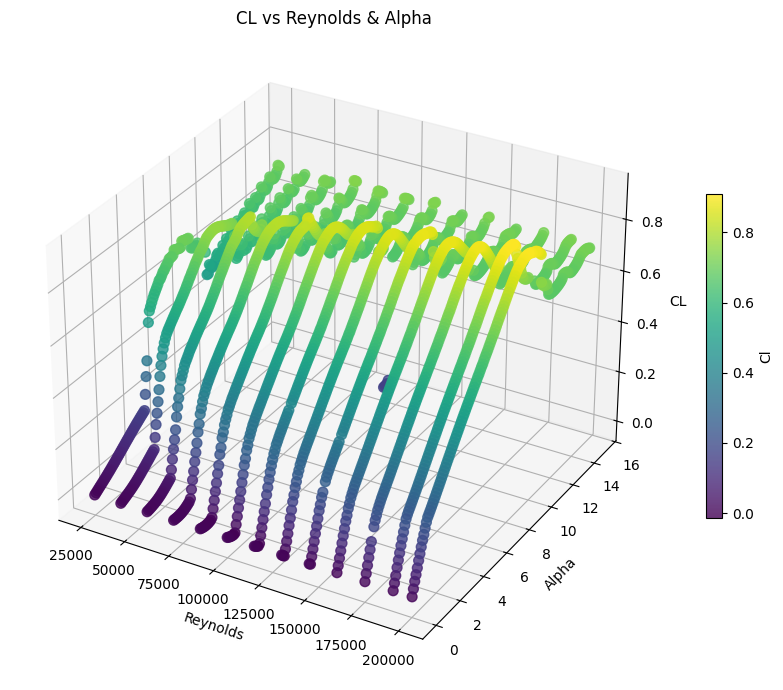

In [5]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

df_unique_naca = df[df.airfoil == "NACA 0010"]

scatter = ax.scatter(
    df_unique_naca['Reynolds'],
    df_unique_naca['alpha'],
    df_unique_naca['CL'],
    c=df_unique_naca['CL'],        # Color points by CL value
    cmap='viridis',
    s=50,
    alpha=0.8
)

ax.set_xlabel('Reynolds')
ax.set_ylabel('Alpha')
ax.set_zlabel('CL')
ax.set_title('CL vs Reynolds & Alpha')

fig.colorbar(scatter, ax=ax, label='Cl', shrink=0.5)
plt.tight_layout()
plt.show()

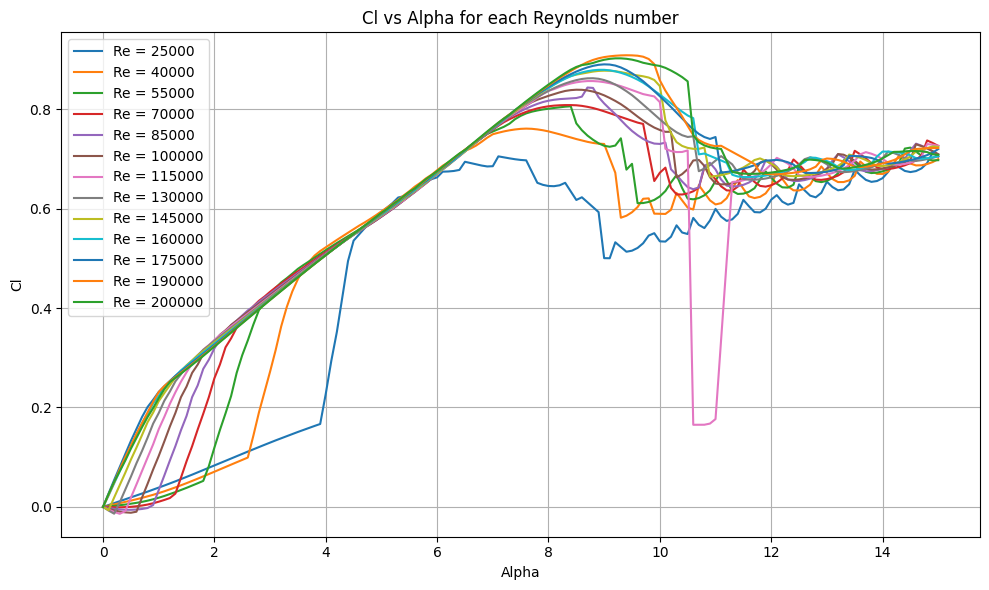

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

for re, group in df_unique_naca.groupby('Reynolds'):
    group_sorted = group.sort_values('alpha')
    ax.plot(group_sorted['alpha'], group_sorted['CL'], label=f'Re = {re:.0f}')

ax.set_xlabel('Alpha')
ax.set_ylabel('Cl')
ax.set_title('Cl vs Alpha for each Reynolds number')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()